# 🌿 Plant Disease Classification (Interactive)

This notebook executes the Hybrid AI approach (ResNet18 + Random Forest) step-by-step.

In [1]:
import os
import cv2
import numpy as np
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Ensure plots display inline
%matplotlib inline

In [2]:
# --- CONFIGURATION ---
# Since we are in a notebook inside 'src', we step back once to get to root
current_dir = Path.cwd()
dataset_path = current_dir.parent / 'dataset'

print(f"📂 Looking for dataset at: {dataset_path}")

📂 Looking for dataset at: d:\University\Final Year CSE\Semester1\Elective 3 Image Processing\Project\PlantVillage\dataset


In [3]:
# --- SETUP RESNET18 ---
print("🧠 Loading ResNet18 (Pre-trained AI)...")
weights = models.ResNet18_Weights.DEFAULT
resnet = models.resnet18(weights=weights)
resnet = torch.nn.Sequential(*(list(resnet.children())[:-1])) # Remove last layer
resnet.eval()

# Image Preprocessing
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def get_vector(img_path):
    input_image = Image.open(img_path).convert('RGB')
    input_tensor = preprocess(input_image)
    input_batch = input_tensor.unsqueeze(0)
    with torch.no_grad():
        output = resnet(input_batch)
    return output.squeeze().numpy()

def load_data_with_ai(base_path):
    features_list = []
    labels_list = []
    class_names = os.listdir(base_path)
    
    print("⏳ Processing images with AI features...")
    
    for class_name in class_names:
        if class_name.startswith('.'): continue # Skip hidden files
        
        class_dir = os.path.join(base_path, class_name)
        if not os.path.isdir(class_dir): continue
        
        # TWEAK: Change [:200] to load more or fewer images
        file_list = os.listdir(class_dir)[:200] 
        print(f"   Extracting features for: {class_name}")
        
        for img_name in file_list:
            img_path = os.path.join(class_dir, img_name)
            try:
                vector = get_vector(img_path)
                features_list.append(vector)
                labels_list.append(class_name)
            except Exception as e:
                print(f"Error reading {img_name}: {e}")
                
    return np.array(features_list), np.array(labels_list)

🧠 Loading ResNet18 (Pre-trained AI)...


In [4]:
# Execute Data Loading
X, y = load_data_with_ai(dataset_path)
print(f"\n✅ Data Processed. Shape: {X.shape}")

⏳ Processing images with AI features...
   Extracting features for: Pepper__bell___Bacterial_spot
   Extracting features for: Pepper__bell___healthy
   Extracting features for: Potato___Early_blight
   Extracting features for: Potato___healthy
   Extracting features for: Potato___Late_blight
   Extracting features for: Tomato_Bacterial_spot
   Extracting features for: Tomato_Early_blight
   Extracting features for: Tomato_healthy
   Extracting features for: Tomato_Late_blight
   Extracting features for: Tomato_Leaf_Mold
   Extracting features for: Tomato_Septoria_leaf_spot
   Extracting features for: Tomato_Spider_mites_Two_spotted_spider_mite
   Extracting features for: Tomato__Target_Spot
   Extracting features for: Tomato__Tomato_mosaic_virus
   Extracting features for: Tomato__Tomato_YellowLeaf__Curl_Virus

✅ Data Processed. Shape: (2952, 512)


In [5]:
# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest
print("🌲 Training Optimized Random Forest...")
rf_model = RandomForestClassifier(n_estimators=500, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"✨ Accuracy: {acc * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

🌲 Training Optimized Random Forest...
✨ Accuracy: 82.23%

Classification Report:
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.91      0.89      0.90        45
                     Pepper__bell___healthy       0.85      0.97      0.91        40
                      Potato___Early_blight       0.90      0.96      0.93        54
                       Potato___Late_blight       0.87      0.79      0.83        43
                           Potato___healthy       0.86      0.90      0.88        20
                      Tomato_Bacterial_spot       0.68      0.86      0.76        37
                        Tomato_Early_blight       0.55      0.44      0.49        41
                         Tomato_Late_blight       0.90      0.51      0.65        35
                           Tomato_Leaf_Mold       0.80      0.92      0.85        38
                  Tomato_Septoria_leaf_spot       0.61      0.70    

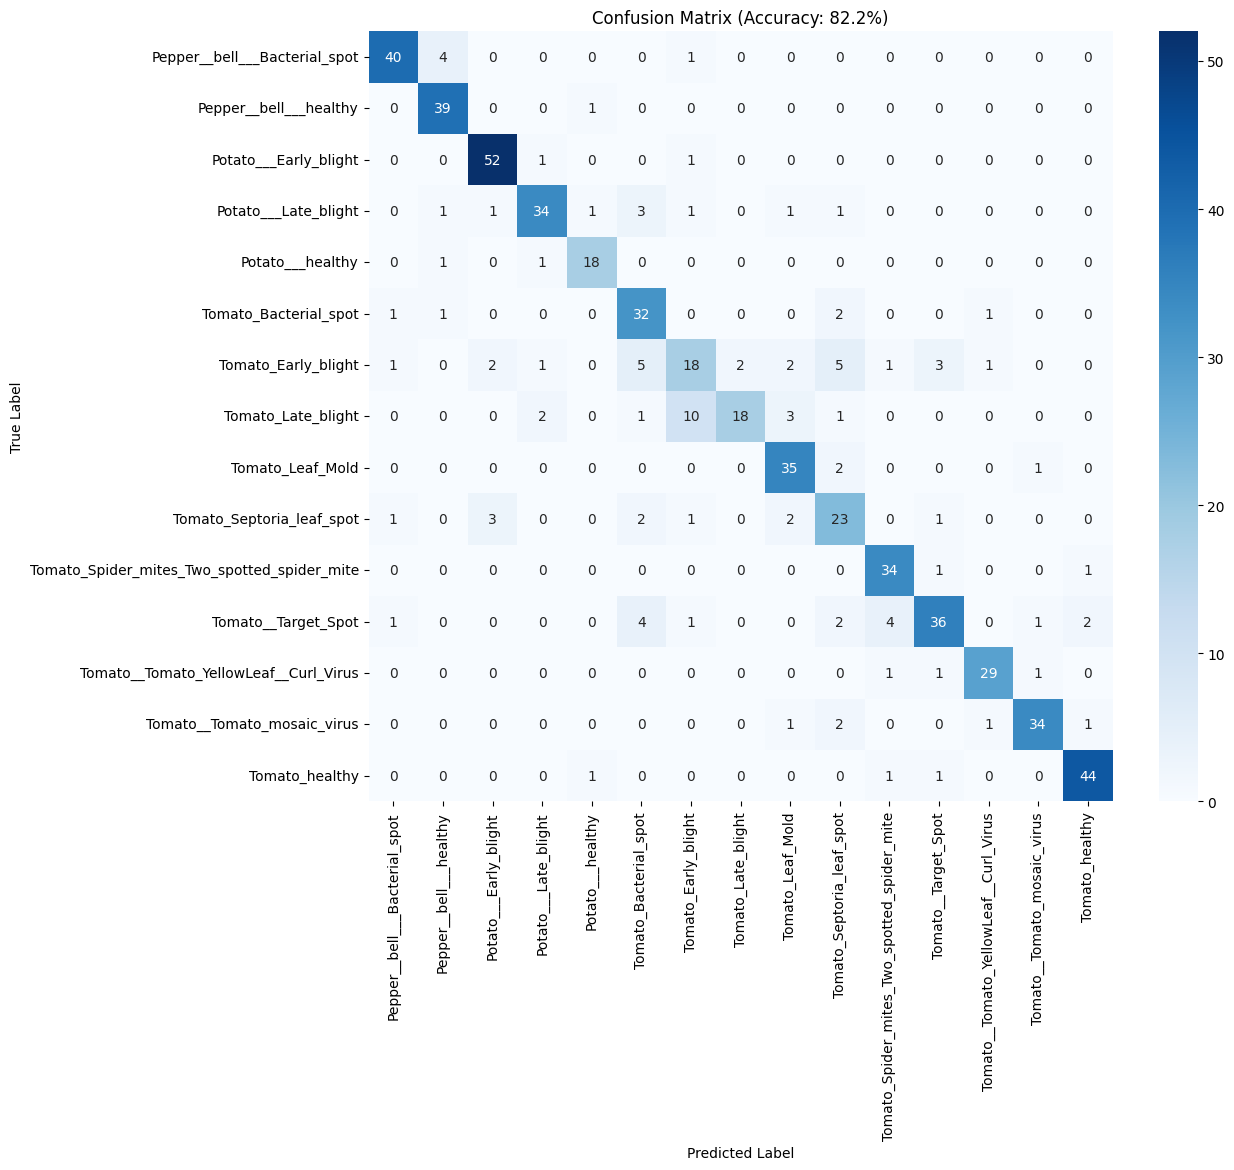

In [6]:
# Confusion Matrix
unique_classes = sorted(list(set(y)))
cm = confusion_matrix(y_test, y_pred, labels=unique_classes)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=unique_classes, yticklabels=unique_classes)
plt.title(f'Confusion Matrix (Accuracy: {acc*100:.1f}%)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=90)
plt.show()